In [81]:
import os
import torch as T
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy import signal
import optuna
#import wandb
import matplotlib.pyplot as plt
import datetime

In [82]:
# === Define FFNN model class ===
class FFNN(nn.Module):
    def __init__(self, lr, input_dims, output_dims, n_hidden, n_nodes,
                 optimizer_name, acts, chkpt_dir='./models', l2=1e-3,
                 name='ffnn', bn=False, dropout = 0.0):
        super(FFNN, self).__init__()
        self.lr = lr
        self.l2 = l2
        self.n_hidden = n_hidden
        self.n_nodes = n_nodes
        self.bn = bn

        self.fc1 = nn.Linear(input_dims, n_nodes)
        self.fcs = nn.ModuleList([nn.Linear(n_nodes, n_nodes) for _ in range(n_hidden)])
        self.bns = nn.ModuleList([nn.BatchNorm1d(n_nodes) for _ in range(n_hidden)]) if bn else None
        self.fc2 = nn.Linear(n_nodes, output_dims)

        self.dropouts = nn.ModuleList([nn.Dropout(dropout) for _ in range(n_hidden)])

        # Safe activation selection
        activation_map = {
            'relu': nn.ReLU,
            'leakyrelu': nn.LeakyReLU,
            'sigmoid': nn.Sigmoid,
            'tanh': nn.Tanh,
            'elu': nn.ELU,
            'selu': nn.SELU,
            'gelu': nn.GELU
        }

        acts_lower = acts.lower()
        if acts_lower in activation_map:
            self.act = activation_map[acts_lower]()
        else:
            raise ValueError(f"Unsupported activation function: {acts}")

        self.output_act = nn.Tanh()
        self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')
        self.to(self.device)
        self.loss = nn.MSELoss()

        opt_class = getattr(optim, optimizer_name)
        self.optimizer = opt_class(self.parameters(), lr=lr, weight_decay=l2)

        self.chkpt_dir = chkpt_dir
        self.checkpoint_file = os.path.join(self.chkpt_dir, f"{name}.pt")

    def normalize_vector(self, data):
        denom = T.sqrt(T.mean(data ** 2, 1))[:, None]
        return data / denom

    def forward(self, state):
        x = self.normalize_vector(state)
        x = self.act(self.fc1(x))
        rms_value = T.sqrt(T.mean(state ** 2, 1))[:, None]
        for idx in range(len(self.fcs)):
            x = self.act(self.fcs[idx](x))
            if self.bn:
                x = self.bns[idx](x)
            x = self.dropouts[idx](x)
            
        output1 = self.output_act(self.fc2(x))
        outputs = self.normalize_vector(output1) * rms_value
        return outputs

    def save_checkpoint(self):
        os.makedirs(self.chkpt_dir, exist_ok=True)
        T.save(self.state_dict(), self.checkpoint_file)

    def load_checkpoint(self):
        self.load_state_dict(T.load(self.checkpoint_file))


In [ ]:


def fft_signal(data_, iota):
    N = 2 ** np.ceil(np.log2(len(data_) * 4))
    f, x = signal.periodogram(data_, window='hann', nfft=N, fs=1e9 * iota, scaling='spectrum')
    f = f / 1e6
    epsilon = 1e-10
    x = 10 * (np.log10((x + epsilon) / 50e-3))
    return [f, x]

def get_data_in_array(dataframe, header_name, delim=True, size=400):
    _results_array = np.zeros([len(dataframe), size])
    for i in range(len(dataframe)):
        _results = dataframe[header_name].iloc[i].strip()[1:-1]
        _results = _results.split(",") if delim else _results.split()
        np_array = [float(value.strip()) for value in _results]
        _results_array[i] = np.array(np_array)[:size]
    return _results_array

def get_data(path, batch_size=64):
    dataset = pd.read_csv(path, skiprows=[0], names=['Numbers', 'Frequencies', 'Powers', 'arcsin_results', 'test_data', 'expected_recovered_freq'])
    x = get_data_in_array(dataset, 'arcsin_results')
    y = get_data_in_array(dataset, 'test_data')

    y = np.resize(y, (y.shape[0], 400))
    x = np.resize(x, (x.shape[0], 400))

    #X_train_data, X_test_data, Y_train_data, Y_test_data = train_test_split(x, y, shuffle=True, random_state=100, test_size=0.25)
    X_train_data, X_val_data, Y_train_data, Y_val_data = train_test_split(x, y, shuffle=True, random_state=100, test_size=0.25)

    train_dataset = T.utils.data.TensorDataset(T.tensor(X_train_data, dtype=T.float), T.tensor(Y_train_data, dtype=T.float))
    #test_dataset = T.utils.data.TensorDataset(T.tensor(X_test_data, dtype=T.float), T.tensor(Y_test_data, dtype=T.float))
    val_dataset = T.utils.data.TensorDataset(T.tensor(X_val_data, dtype=T.float), T.tensor(Y_val_data, dtype=T.float))

    train_loader = T.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    #test_loader = T.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    val_loader = T.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

def get_test_data(path, batch_size=64):
    dataset = pd.read_csv(path, skiprows=[0], names=['Numbers', 'Frequencies', 'Powers', 'arcsin_results', 'test_data', 'expected_recovered_freq'])
    x = get_data_in_array(dataset, 'arcsin_results')
    y = get_data_in_array(dataset, 'test_data')

    y = np.resize(y, (y.shape[0], 400))
    x = np.resize(x, (x.shape[0], 400))

    #X_train_data, X_test_data, Y_train_data, Y_test_data = train_test_split(x, y, shuffle=True, random_state=100, test_size=0.25)
    #X_train_data, X_val_data, Y_train_data, Y_val_data = train_test_split(x, y, shuffle=True, random_state=100, test_size=0.25)

    test_dataset = T.utils.data.TensorDataset(T.tensor(x, dtype=T.float), T.tensor(y, dtype=T.float))
    #test_dataset = T.utils.data.TensorDataset(T.tensor(X_test_data, dtype=T.float), T.tensor(Y_test_data, dtype=T.float))
    #val_dataset = T.utils.data.TensorDataset(T.tensor(X_val_data, dtype=T.float), T.tensor(Y_val_data, dtype=T.float))

    test_loader = T.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
    #test_loader = T.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    #val_loader = T.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return test_loader

def train(model, train_loader, val_loader, epochs, patience, val_freq=10):
    best_val_loss = float('inf')
    early_stopping_counter = 0
    mse = lambda x, y: np.mean((x - y) ** 2)
    train_loss_history = []
    val_loss_history = []
    for epoch in range(epochs):
        model.train()
        losses = []
        for data, targets in train_loader:
            data, targets = data.to(model.device), targets.to(model.device)
            model.optimizer.zero_grad()
            outputs = model(data)
            loss = model.loss(outputs, targets)
            loss.backward()
            model.optimizer.step()
            losses.append(loss.item())

        avg_train_loss_history = np.mean(losses)
        train_loss_history.append(avg_train_loss_history)
        #wandb.log({"train_loss": np.mean(losses), "epoch": epoch})

        if epoch % val_freq == 0:
            model.eval()
            val_losses = []
            with T.no_grad():
                for data, targets in val_loader:
                    data, targets = data.to(model.device), targets.to(model.device)
                    outputs = model(data)
                    val_losses.append(mse(outputs.cpu().numpy(), targets.cpu().numpy()))
            val_loss = np.mean(val_losses)
            val_loss_history.append((epoch, val_loss))
            #wandb.log({"validation_loss": val_loss})

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                early_stopping_counter = 0
                model.save_checkpoint()
            else:
                early_stopping_counter += 1
            if early_stopping_counter >= patience:
                break
            #else:
             #   val_loss_history.append((epoch, None))
        print(f"epoch {epoch} completed!!")
    return train_loss_history, val_loss_history

In [84]:
def plot_losses(train_loss, val_loss, figure, trial_id=None):
    epochs = range(len(train_loss))
    val_epochs = [e for e, v in val_loss if v is not None]
    val_values = [v for e, v in val_loss if v is not None]

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(val_epochs, val_values, label="Validation Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss{' - Trial ' + str(trial_id) if trial_id else ''}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'./plots/loss_{figure}.png')
    plt.show()

    plt.close()
    


In [85]:
def test_regression(model, test_loader):
    model.load_checkpoint()
    model.eval()
    mse = lambda x, y: np.mean((x - y) ** 2)
    mse_array = []
    with T.no_grad():
        for data, targets in test_loader:
            data = data.to(model.device)
            targets = targets.to(model.device)
            outputs = model(data).cpu().numpy()
            mse_array.append(mse(targets.cpu().numpy(), outputs))
    avg_loss = np.mean(mse_array)
    print('Test MSE:', avg_loss)
    #wandb.log({"avg_test_loss": avg_loss})

In [86]:
def plot_random_samples(model, train_loader, figure, num_samples=6):
    import random
    model.load_checkpoint()
    model.eval()
    indices = random.sample(range(len(train_loader.dataset)), num_samples)
    samples = [train_loader.dataset[i] for i in indices]
    fig, ax = plt.subplots(2, 3, figsize=(12, 8))
    fig_fft, ax_fft = plt.subplots(2, 3, figsize=(12, 8))
    mse = []
    for i, (data, target) in enumerate(samples):
        data = data.to(model.device)
        target = target.to(model.device)
        with T.no_grad():
            prediction = model(data.unsqueeze(0)).squeeze().cpu().numpy()
        target = target.cpu().numpy()
        data = data.cpu().numpy()
        mse.append(np.mean((target - prediction) ** 2))
        row, col = i // 3, i % 3
        ax[row][col].plot(data, label='Input Data', color='blue')
        ax[row][col].plot(target, 'g', label='Target')
        ax[row][col].plot(prediction, 'r', label='Prediction')
        ax[row][col].set_title(f"sample {i+1}_{figure}")
        ax[row][col].set_xlabel("time (ns)")
        ax[row][col].set_ylabel('Amplitude (V)')
        ax[row][col].legend()



        f_data, x_data = fft_signal(data, iota=2)
        f_pred, x_pred = fft_signal(prediction, iota=2)
        f_tgt, x_tgt = fft_signal(target, iota=2)
        ax_fft[row][col].plot(f_data, x_data, label='Input')
        ax_fft[row][col].plot(f_tgt, x_tgt, 'g', label='Target')
        ax_fft[row][col].plot(f_pred, x_pred, 'r', label='Predicted')
        ax_fft[row][col].set_title(f"sample {i+1}_{figure}")
        ax_fft[row][col].set_xlabel("Frequency (MHz)")
        ax_fft[row][col].set_ylabel("Power (dBm)")
        ax_fft[row][col].set_xlim(0,500)
        ax_fft[row][col].legend()
    plt.tight_layout()
    fig.savefig(f'./plots/samples_{figure}.png')
    fig_fft.savefig(f'./plots/samples_fft_{figure}.png')
    #wandb.log({"samples": wandb.Image('samples.png'), "samples_fft": wandb.Image('samples_fft.png')})
    print("Mean sample MSE:", np.mean(mse))

In [87]:
def objective(trial):
    day = datetime.datetime.today().strftime("%d%m%Y%H")
    name = f"run_{trial.number + 1}_{day}"
    #name = f"run_{trial.number + 1}"
    #wandb.init(project="Entity-01", name= name)
    config = {
        "lr": trial.suggest_float('lr', 1e-7, 1e-2, log = True),
        "n_hidden": trial.suggest_int('n_hidden', 4, 15),
        "n_nodes": trial.suggest_categorical('n_nodes', [256, 512, 1024, 2048]),
        "optim": trial.suggest_categorical('optim', ['Adam', 'RMSprop', 'SGD', 'Adagrad', 'Adadelta', 'AdamW']),
        "acts": trial.suggest_categorical('acts', ['relu', 'tanh', 'selu', 'elu']),
        "l2": trial.suggest_float('l2', 1e-6, 1e-2, log = True),
        "batch_size": trial.suggest_categorical('batch_size', [512, 1024, 2048, 4096]),
        "bn": trial.suggest_categorical('bn', [True, False]),
        "dropout": trial.suggest_float('dropout', 0.01, 0.2)
    }
    #wandb.config.update(config)
    train_loader, val_loader = get_data('pvary_fvary_train_data.csv', config['batch_size'])
    test_loader = get_test_data('pvary_fvary_test_data.csv', batch_size=config['batch_size'])
    model = FFNN(lr=config['lr'], input_dims=400, output_dims=400, n_hidden=config['n_hidden'], n_nodes=config['n_nodes'],
                 optimizer_name=config['optim'], acts=config['acts'], l2=config['l2'], name=name, bn=config['bn'], dropout=config['dropout'])
    train_loss, val_loss = train(model, train_loader, val_loader, epochs=2500, patience=15)
    model.load_checkpoint()
    model.eval()
    test_regression(model, test_loader)
    plot_losses(train_loss=train_loss, val_loss= val_loss, figure=name, trial_id= trial.number + 1)
    plot_random_samples(model, test_loader, figure=f"{name}", num_samples=6)
    mse = lambda x, y: np.mean((x - y) ** 2)
    val_losses = []
    with T.no_grad():
        for data, targets in val_loader:
            data, targets = data.to(model.device), targets.to(model.device)
            outputs = model(data)
            val_losses.append(mse(outputs.cpu().numpy(), targets.cpu().numpy()))
    avg_val_loss = np.mean(val_losses)
    #wandb.log({"final_val_loss": avg_val_loss})
    return avg_val_loss

epoch 0 completed!!
epoch 1 completed!!
epoch 2 completed!!
epoch 3 completed!!
epoch 4 completed!!
epoch 5 completed!!
epoch 6 completed!!
epoch 7 completed!!
epoch 8 completed!!
epoch 9 completed!!
epoch 10 completed!!
epoch 11 completed!!
epoch 12 completed!!
epoch 13 completed!!
epoch 14 completed!!
epoch 15 completed!!
epoch 16 completed!!
epoch 17 completed!!
epoch 18 completed!!
epoch 19 completed!!
epoch 20 completed!!
epoch 21 completed!!
epoch 22 completed!!
epoch 23 completed!!
epoch 24 completed!!
epoch 25 completed!!
epoch 26 completed!!
epoch 27 completed!!
epoch 28 completed!!
epoch 29 completed!!
epoch 30 completed!!
epoch 31 completed!!
epoch 32 completed!!
epoch 33 completed!!
epoch 34 completed!!
epoch 35 completed!!
epoch 36 completed!!
epoch 37 completed!!
epoch 38 completed!!
epoch 39 completed!!
epoch 40 completed!!
epoch 41 completed!!
epoch 42 completed!!
epoch 43 completed!!
epoch 44 completed!!
epoch 45 completed!!
epoch 46 completed!!
epoch 47 completed!!
ep

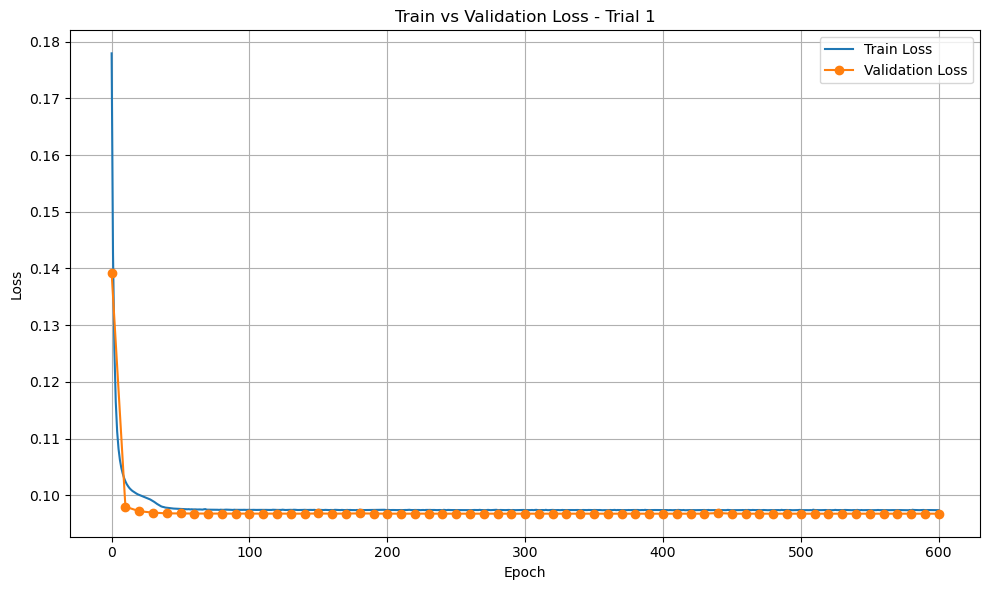

C:\Users\student\AppData\Local\Temp\ipykernel_17204\295117838.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(T.load(self.checkpoint_file))


Mean sample MSE: 0.36711767


C:\Users\student\AppData\Local\Temp\ipykernel_17204\295117838.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(T.load(self.checkpoint_file))


Test MSE: 0.19008262


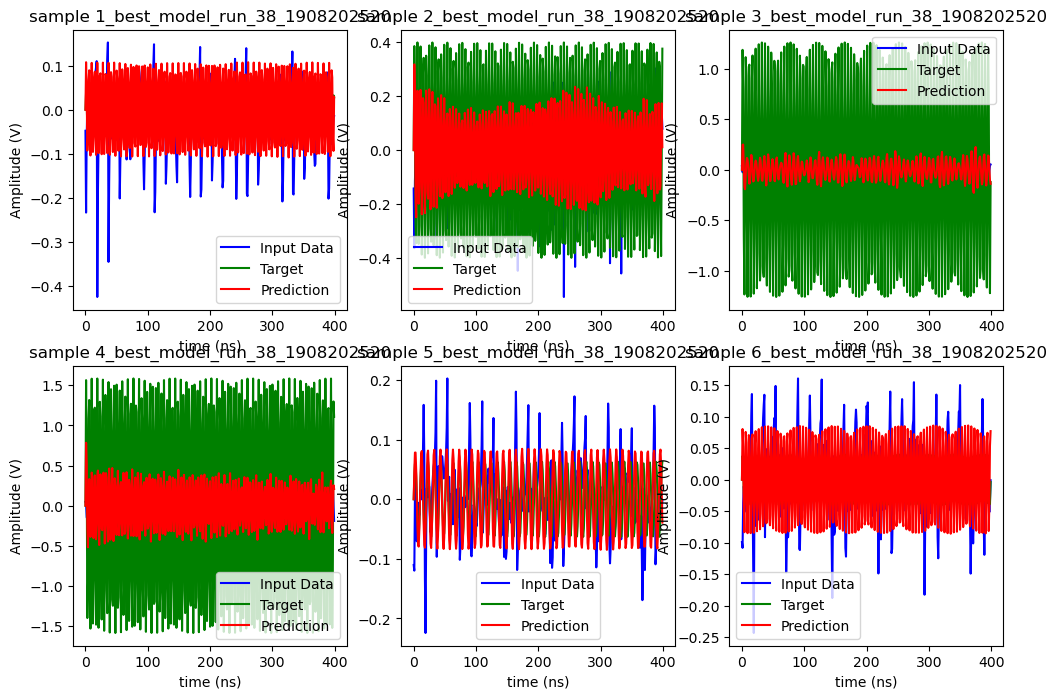

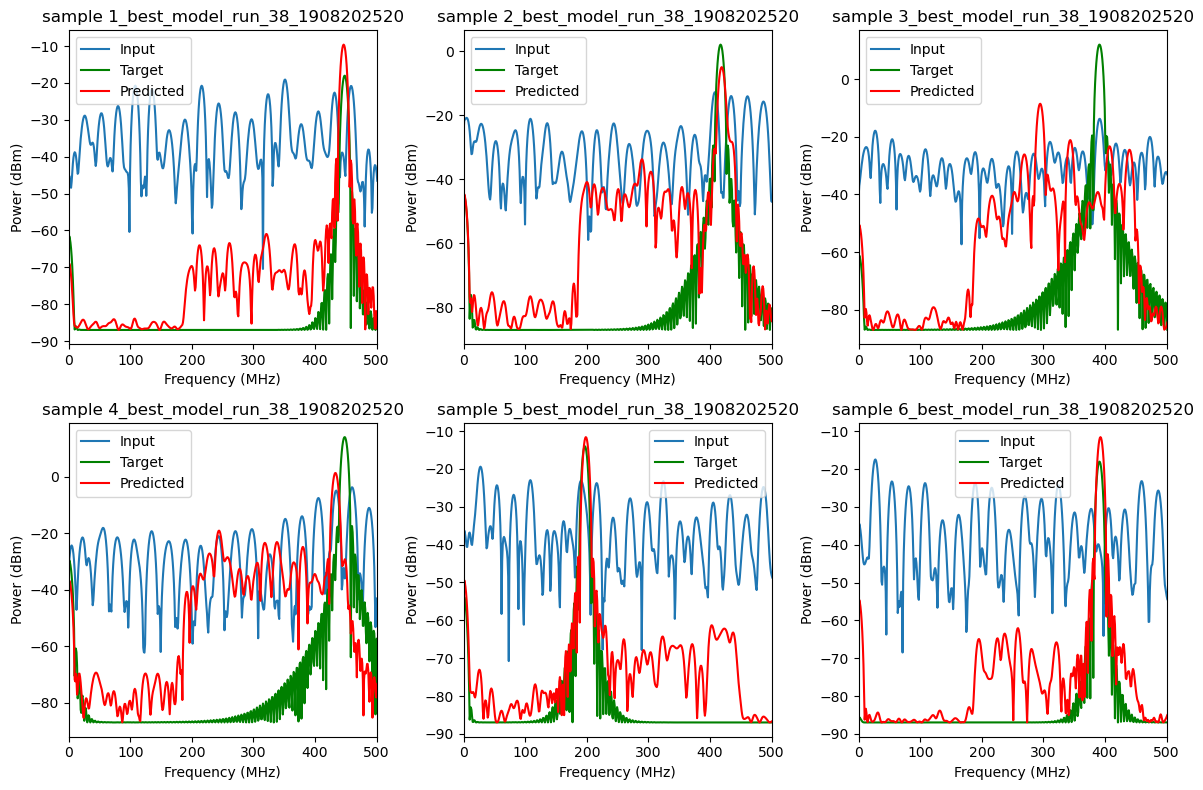

In [88]:
if __name__ == '__main__':
    day = datetime.datetime.today().strftime("%d%m%Y%H")
    '''study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50)
    print("Best trial:", study.best_trial)
    df = study.trials_dataframe()
    
    df.to_csv(f'trails_hyperparams_{day}.csv', index=False)
    best_params = study.best_trial.params
    with open (f"best_params.txt", "w") as f:
        for key, value in best_params.items():
            f.write(f"{key}: {value}\n")'''

    model = FFNN(lr=0.0001642957081, input_dims=400, output_dims=400, n_hidden=6,
                 n_nodes=512, optimizer_name='AdamW', acts='elu',
                 l2=7.06E-05, dropout=0.167091046, name=f'final_model_{day}_run_38', bn=True)
    train_loader, val_loader = get_data('pvary_fvary_train_data.csv', batch_size= 4096)
    test_loader = get_test_data('pvary_fvary_offline_data.csv', batch_size= 4096)
    
    train_loss, val_loss = train(model, train_loader, val_loader, epochs=8500, patience=15)
    plot_losses(train_loss=train_loss, val_loss=val_loss, figure = f'test_model_{day}', trial_id= 1)
    plot_random_samples(model, test_loader, f'best_model_run_38_{day}', 6)

    _, loader = get_data('pvary_fvary_train_data.csv', batch_size=1)
    example_input, _ = next(iter(loader))  # Get one batch
    example_input = example_input.to(model.device)

    traced_model = T.jit.trace(model, example_input)
    T.jit.save(traced_model, f"final_model_{day}_run_38.pt")


    model.load_checkpoint()
    model.eval()
    
    test_regression(model, test_loader)
    #plot_random_samples(model, test_loader, figure= 'best')

    